<a href="https://colab.research.google.com/github/amiy75/Tugas-Pemrosesan-Teks_-Text-Processing/blob/main/Text_Processing_QuantaMagazine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd

df = pd.read_csv("quanta_physics_articles.csv")
df.head()

,Title,Author,Date,Summary,Processed_text
0,Gravity Seems Holographic. What Does That Mean...,Charlie Wood,"September 25, 2026",The biggest breakthrough in modern theoretical...,biggest breakthrough modern theoretical physic...
1,"Biology Might Not Be Quantum, but Its Math Is ...",Elise Cutts,"September 23, 2026",Scientists have a history of trying — and fail...,scientist history trying failing link biology ...
2,Where Does the Quantum World End and Ours Begin?,Steven Strogatz,"September 17, 2026",Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains quantum decoherenc...
3,Black Holes or Black Hole Stars? Astronomers S...,Charlie Wood,"September 14, 2026",The James Webb Space Telescope spots mysteriou...,james webb space telescope spot mysterious lit...
4,"In Hilbert Space, All Things Are Quantumly Pos...",Charlie Wood,"August 26, 2026","To explore quantum phenomena, we must leave th...",explore quantum phenomenon must leave familiar...


In [52]:
text = df["Summary"]
text.head()

,Summary
0,The biggest breakthrough in modern theoretical...
1,Scientists have a history of trying — and fail...
2,Jonathan Halliwell explains how quantum decohe...
3,The James Webb Space Telescope spots mysteriou...
4,"To explore quantum phenomena, we must leave th..."



**Mengubah semua huruf menjadi huruf kecil (Case Folding)**



In [53]:
df["Summary_lower"] = df["Summary"].str.lower()

# Membandingkan sebelum dan sesudah case folding
df[["Summary", "Summary_lower"]].head()

,Summary,Summary_lower
0,The biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...
1,Scientists have a history of trying — and fail...,scientists have a history of trying — and fail...
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...
3,The James Webb Space Telescope spots mysteriou...,the james webb space telescope spots mysteriou...
4,"To explore quantum phenomena, we must leave th...","to explore quantum phenomena, we must leave th..."


**Cleaning**

In [54]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""

    # Menghapus URL
    text = re.sub(r"http\S+", " ", text)

    # Mengganti karakter selain huruf dengan spasi
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Menghapus spasi yang berlebihan
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["Summary_clean"] = df["Summary_lower"].apply(clean_text)

df[["Summary_lower", "Summary_clean"]].head()

,Summary_lower,Summary_clean
0,the biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...
1,scientists have a history of trying — and fail...,scientists have a history of trying and failin...
2,jonathan halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...
3,the james webb space telescope spots mysteriou...,the james webb space telescope spots mysteriou...
4,"to explore quantum phenomena, we must leave th...",to explore quantum phenomena we must leave the...


**Tokenisasi**

In [55]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

df["Tokens"] = df["Summary_clean"].apply(word_tokenize)

df[["Summary_clean", "Tokens"]].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Summary_clean,Tokens
0,the biggest breakthrough in modern theoretical...,"[the, biggest, breakthrough, in, modern, theor..."
1,scientists have a history of trying and failin...,"[scientists, have, a, history, of, trying, and..."
2,jonathan halliwell explains how quantum decohe...,"[jonathan, halliwell, explains, how, quantum, ..."
3,the james webb space telescope spots mysteriou...,"[the, james, webb, space, telescope, spots, my..."
4,to explore quantum phenomena we must leave the...,"[to, explore, quantum, phenomena, we, must, le..."


**Stopword Removal**

In [56]:
import nltk #Library berbasis bahasa pemrograman Python
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
df["Tokens_no_stop"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)
df[["Tokens", "Tokens_no_stop"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Tokens,Tokens_no_stop
0,"[the, biggest, breakthrough, in, modern, theor...","[biggest, breakthrough, modern, theoretical, p..."
1,"[scientists, have, a, history, of, trying, and...","[scientists, history, trying, failing, link, b..."
2,"[jonathan, halliwell, explains, how, quantum, ...","[jonathan, halliwell, explains, quantum, decoh..."
3,"[the, james, webb, space, telescope, spots, my...","[james, webb, space, telescope, spots, mysteri..."
4,"[to, explore, quantum, phenomena, we, must, le...","[explore, quantum, phenomena, must, leave, fam..."


**Lemmatization**

In [57]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["Lemma"] = df["Tokens_no_stop"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[["Tokens_no_stop", "Lemma"]].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens_no_stop,Lemma
0,"[biggest, breakthrough, modern, theoretical, p...","[biggest, breakthrough, modern, theoretical, p..."
1,"[scientists, history, trying, failing, link, b...","[scientist, history, trying, failing, link, bi..."
2,"[jonathan, halliwell, explains, quantum, decoh...","[jonathan, halliwell, explains, quantum, decoh..."
3,"[james, webb, space, telescope, spots, mysteri...","[james, webb, space, telescope, spot, mysterio..."
4,"[explore, quantum, phenomena, must, leave, fam...","[explore, quantum, phenomenon, must, leave, fa..."


In [58]:
# Menampilkan hasil setiap tahap text preprocessing
df[
    [
        "Summary",
        "Summary_lower",
        "Summary_clean",
        "Tokens",
        "Tokens_no_stop",
        "Lemma"
    ]
].head(3)

,Summary,Summary_lower,Summary_clean,Tokens,Tokens_no_stop,Lemma
0,The biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...,"[the, biggest, breakthrough, in, modern, theor...","[biggest, breakthrough, modern, theoretical, p...","[biggest, breakthrough, modern, theoretical, p..."
1,Scientists have a history of trying — and fail...,scientists have a history of trying — and fail...,scientists have a history of trying and failin...,"[scientists, have, a, history, of, trying, and...","[scientists, history, trying, failing, link, b...","[scientist, history, trying, failing, link, bi..."
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...,"[jonathan, halliwell, explains, how, quantum, ...","[jonathan, halliwell, explains, quantum, decoh...","[jonathan, halliwell, explains, quantum, decoh..."


In [59]:
df["Processed_text"] = df["Lemma"].apply(
    lambda words: " ".join(words)
)

df[["Summary", "Processed_text"]].head()

,Summary,Processed_text
0,The biggest breakthrough in modern theoretical...,biggest breakthrough modern theoretical physic...
1,Scientists have a history of trying — and fail...,scientist history trying failing link biology ...
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains quantum decoherenc...
3,The James Webb Space Telescope spots mysteriou...,james webb space telescope spot mysterious lit...
4,"To explore quantum phenomena, we must leave th...",explore quantum phenomenon must leave familiar...


**Melihat kata yang sering muncul menggunakan WordCloud dan Bar Chart**

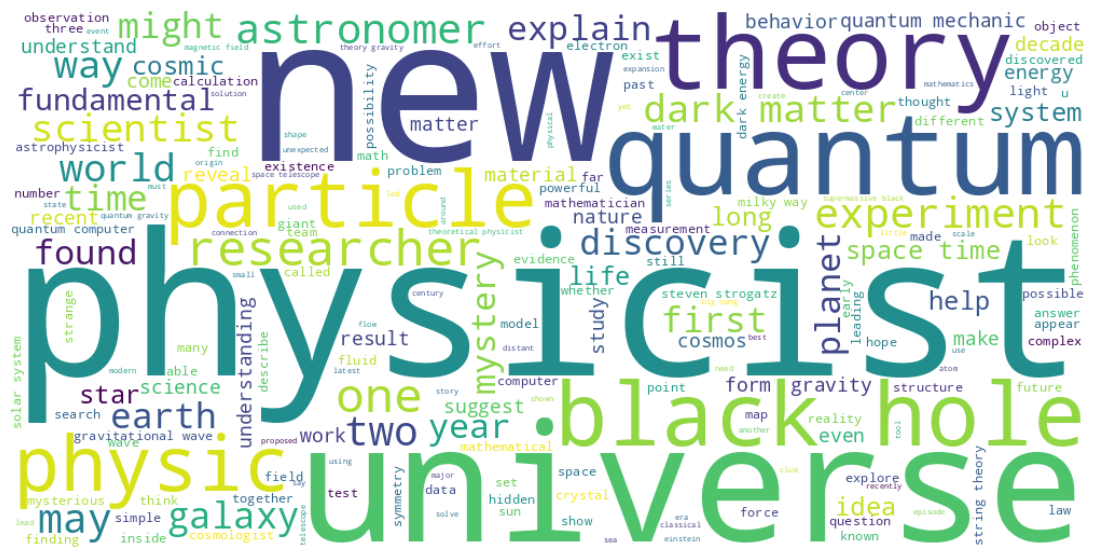

In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = []

for words in df["Lemma"]:
    all_words.extend(words)

text_for_wordcloud = " ".join(all_words)
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_for_wordcloud)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

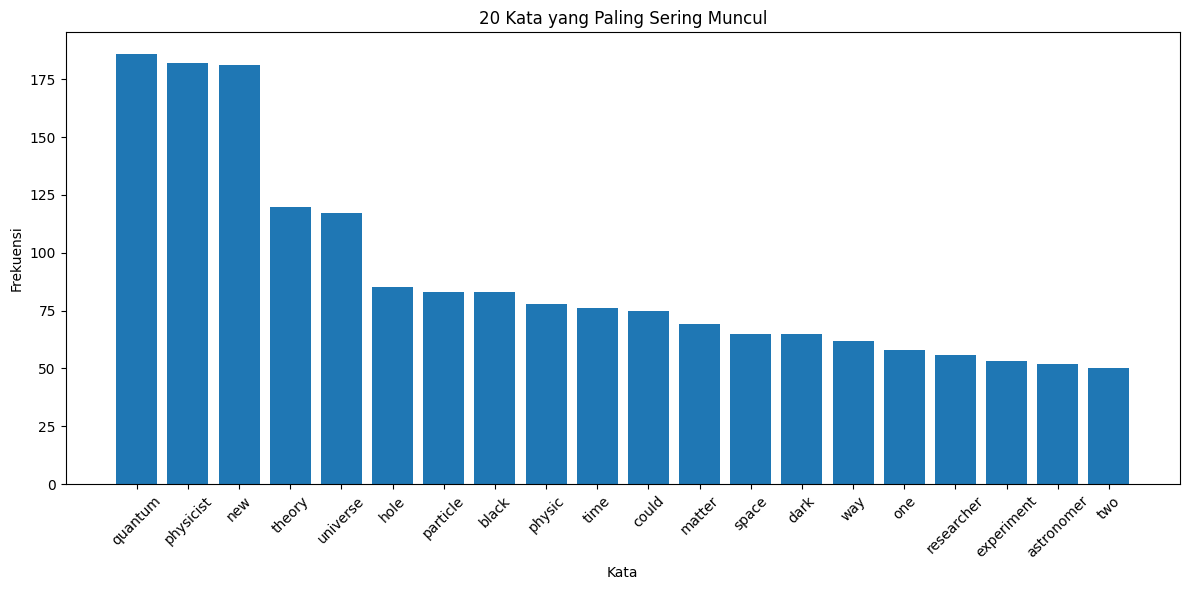

In [61]:
from collections import Counter
import matplotlib.pyplot as plt

word_frequency = Counter(all_words)

top_words = word_frequency.most_common(20)

words = [word for word, count in top_words]
frequencies = [count for word, count in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, frequencies)

plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title("20 Kata yang Paling Sering Muncul")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
print("Jumlah data:", len(df))
print("Summary kosong:", df["Summary"].isna().sum())
print("Summary_clean kosong:", (df["Summary_clean"] == "").sum())
print("Processed_text kosong:", (df["Processed_text"] == "").sum())
print("Jumlah duplikat Title:", df.duplicated(subset="Title").sum())

Jumlah data: 775
Summary kosong: 0
Summary_clean kosong: 0
Processed_text kosong: 0
Jumlah duplikat Title: 0


In [63]:
df.to_csv("quanta_physics_preprocessing.csv", index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


In [64]:
from google.colab import files

files.download("quanta_physics_preprocessing.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>